| 字段名 | 含义说明 |
|--------|----------|
| **survived** | 生存情况，用数字表示：`0` 代表死亡，`1` 代表生还 |
| **pclass** | 客舱等级，数字编码：`1` = 一等舱，`2` = 二等舱，`3` = 三等舱 |
| **sex** | 乘客性别，取值为 `male`（男性）或 `female`（女性） |
| **age** | 乘客年龄（岁），存在缺失值 |
| **sibsp** | 同行的兄弟姐妹及配偶人数 |
| **parch** | 同行的父母及子女人数 |
| **fare** | 乘客购买的船票价格 |
| **embarked** | 登船港口代码：`C` = Cherbourg，`Q` = Queenstown，`S` = Southampton |
| **class** | 客舱等级的类别描述，与 `pclass` 一一对应：`First`，`Second`，`Third` |
| **who** | 根据性别和年龄划分的人员类别：`man`（成年男性），`woman`（成年女性），`child`（儿童） |
| **adult_male** | 是否为成年男性：`True` 表示是成年男性，`False` 不是 |
| **deck** | 客舱所在的甲板编号（A/B/C 等），缺失值比例很高 |
| **embark_town** | 登船城市全称：`Cherbourg`，`Queenstown`，`Southampton`；与 `embarked` 对应 |
| **alive** | 生存情况的文字描述：`yes`（生还），`no`（死亡），与 `survived` 信息重复 |
| **alone** | 是否独自一人（无任何亲属同行）：当 `sibsp` 和 `parch` 均为 0 时为 `True`，否则为 `False` |

In [45]:
import pandas as pd
import numpy as np


In [46]:
# 读取数据
titanic = pd.read_csv('titanic.csv')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [47]:
# deck缺失值直接删除
titanic.drop('deck', axis=1, inplace=True)
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [48]:
# 年龄的均值进行缺失值的填充（仅仅年龄有缺失值）
# 拿到年龄平均值
age_mean = titanic['age'].mean()
# 对年龄字段进行填充
titanic.fillna(value={'age': age_mean}, inplace=True)
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [49]:
# 使用 duplicated() 检测数据集中是否存在完全相同的行并调用 drop_duplicates() 进行去重。
titanic.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886     True
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [50]:
# 886行有重复值
titanic.drop_duplicates(inplace=True)
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.000000,0,5,29.1250,Q,Third,woman,False,Queenstown,no,False
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [51]:
# 保留alive、class、embarked、alone，删除survived、pclass、embark_town、sibsp、parch、who、adult_male
drop_list = ['survived', 'pclass', 'embark_town', 'sibsp', 'parch', 'who', 'adult_male']
for key in drop_list:
    titanic.drop(key, axis=1, inplace=True)
titanic

,sex,age,fare,embarked,class,alive,alone
0,male,22.000000,7.2500,S,Third,no,False
1,female,38.000000,71.2833,C,First,yes,False
2,female,26.000000,7.9250,S,Third,yes,True
3,female,35.000000,53.1000,S,First,yes,False
4,male,35.000000,8.0500,S,Third,no,True
...,...,...,...,...,...,...,...
885,female,39.000000,29.1250,Q,Third,no,False
887,female,19.000000,30.0000,S,First,yes,True
888,female,29.699118,23.4500,S,Third,no,False
889,male,26.000000,30.0000,C,First,yes,True


In [52]:
# 导入matplotlib库中的pyplot模块，并将其简称为plt，用于绘图
import matplotlib.pyplot as plt
# 在Jupyter Notebook或类似环境中使用此命令，可以直接在notebook中显示图形，而不是弹出新窗口
%matplotlib inline

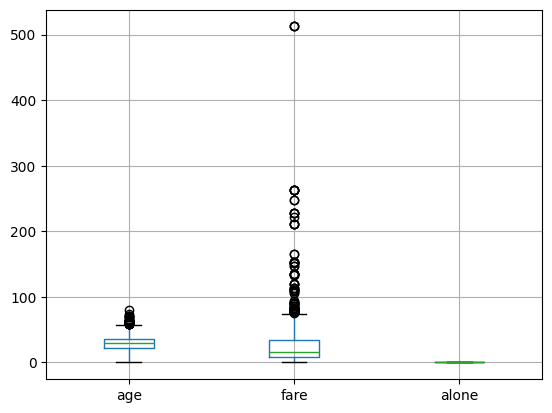

In [53]:
# 使用pandas库的DataFrame和matplotlib库进行数据可视化
titanic.boxplot()  # 绘制箱线图
plt.show()  # 显示图形

In [54]:
def fill_outliers_with_mean(series):
    # 用箱线图方法识别异常值，并用该列的均值替换
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR   # 下须
    upper = Q3 + 1.5 * IQR   # 上须
    # 拿到这整个列表每个数值字段的均值
    mean_val = series.mean()
    # 将超过上下须的值替换为均值
    series_new = series.where((series >= lower) & (series <= upper), mean_val)
    return series_new

# 对 age 和 fare 进行异常值处理
titanic['age'] = fill_outliers_with_mean(titanic['age'])
titanic['fare'] = fill_outliers_with_mean(titanic['fare'])
titanic

,sex,age,fare,embarked,class,alive,alone
0,male,22.000000,7.2500,S,Third,no,False
1,female,38.000000,71.2833,C,First,yes,False
2,female,26.000000,7.9250,S,Third,yes,True
3,female,35.000000,53.1000,S,First,yes,False
4,male,35.000000,8.0500,S,Third,no,True
...,...,...,...,...,...,...,...
885,female,39.000000,29.1250,Q,Third,no,False
887,female,19.000000,30.0000,S,First,yes,True
888,female,29.699118,23.4500,S,Third,no,False
889,male,26.000000,30.0000,C,First,yes,True
